In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# === STEP 1: Load Data ===
df = pd.read_csv("/Users/nithish/Downloads/sensor_data_export_20250606_154020.csv")


In [5]:
# === STEP 2: Preprocess ===
features = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
X = df[features]
y = df['activity']

# Drop rows with missing values
X_clean = X.dropna()
y_clean = y[X_clean.index]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

In [6]:
# === STEP 3: Train-Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

In [7]:
# === STEP 4: Train Model ===
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [10]:
# === STEP 5: Predict & Evaluate ===
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
report = classification_report(y_test, y_pred)

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)
accuracy = accuracy_score(y_test, y_pred)

print("✅ Decision Tree Activity Recognition")
print(f"🎯 Accuracy: {accuracy:.4f}\n")
print("📉 Classification Report:\n", report)


✅ Decision Tree Activity Recognition
🎯 Accuracy: 0.9025

📉 Classification Report:
               precision    recall  f1-score   support

    freefall       0.94      0.97      0.96       181
     turning       0.76      0.70      0.73        40
turning_fast       0.75      0.60      0.67        15

    accuracy                           0.90       236
   macro avg       0.82      0.76      0.78       236
weighted avg       0.90      0.90      0.90       236



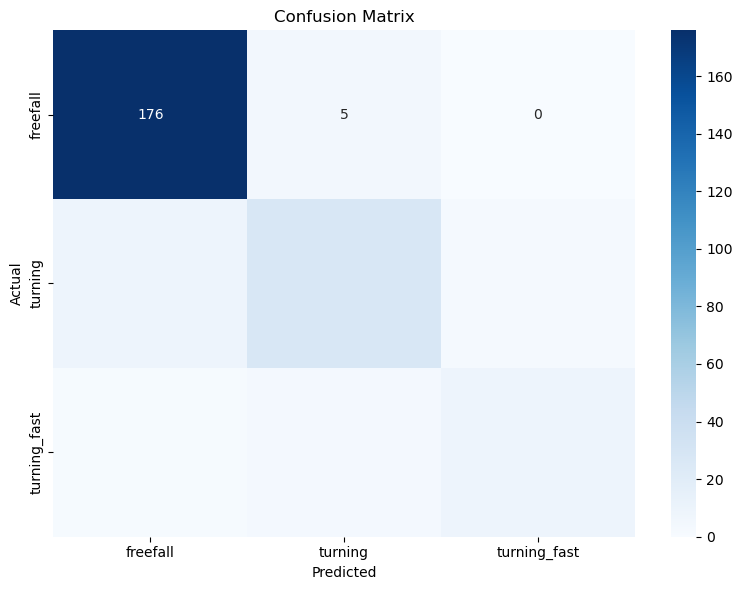

In [11]:
# === STEP 6: Visualize Confusion Matrix ===
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d",
            xticklabels=model.classes_, yticklabels=model.classes_,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/Users/nithish/Downloads/confusion_matrix.png")
plt.show()

In [15]:
import pandas as pd
import joblib
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# === 1. Load model and scaler ===
model = joblib.load("/Users/nithish/Downloads/activity_model.joblib")
scaler = joblib.load("/Users/nithish/Downloads/scaler.joblib")

# === 2. Load input sensor data ===
df = pd.read_csv("/Users/nithish/Downloads/simulated_walking_sensor_data.csv")  # <--- Change to your file path

# Predict Activity

In [12]:
# === 3. Predict activity ===
features = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
X = df[features].dropna()
X_scaled = scaler.transform(X)
preds = model.predict(X_scaled)

df = df.loc[X.index]  # Align indexes
df['predicted_activity'] = preds


# Step Counting

In [13]:
# === 4. Step Counting from accel_z ===
if 'accel_z' in df.columns:
    accel_z = df['accel_z'].reset_index(drop=True)
    peaks, _ = find_peaks(accel_z, height=9.7, distance=10)
    step_count = len(peaks)
    print(f"👣 Estimated Steps: {step_count}")

    # Optional: Plot steps
    plt.figure(figsize=(12, 5))
    plt.plot(accel_z, label='accel_z', alpha=0.7)
    plt.plot(peaks, accel_z[peaks], "x", color="red", label='Detected Steps')
    plt.title(f"Step Count Plot | Steps Detected: {step_count}")
    plt.xlabel("Time Index")
    plt.ylabel("accel_z (Vertical Acceleration)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("/Users/nithish/Downloads/step_count_plot.png")
    plt.close()
else:
    print("⚠️ accel_z column not found!")
    step_count = 0

👣 Estimated Steps: 21


In [14]:
# === 5. Save combined output ===
df['step_count'] = step_count  # Optional: you can leave this off if you want per-frame logic
output_path = "/Users/nithish/Downloads/final_output_activity_and_steps.csv"
df.to_csv(output_path, index=False)

print(f"✅ Output saved to: {output_path}")

✅ Output saved to: /Users/nithish/Downloads/final_output_activity_and_steps.csv


# Model testing with sample data

In [19]:
import pandas as pd
import joblib
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# === 1. Load model and scaler ===
model = joblib.load("/Users/nithish/Downloads/activity_model.joblib")
scaler = joblib.load("/Users/nithish/Downloads/scaler.joblib")

# === 2. Load data ===
df = pd.read_csv("/Users/nithish/Downloads/simulated_walking_sensor_data.csv")
features = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
X = df[features].dropna()
X_scaled = scaler.transform(X)

# === 3. Predict activities ===
predicted_activities = model.predict(X_scaled)
df = df.loc[X.index]
df['predicted_activity'] = predicted_activities

# === 4. Find dominant activity (most frequent one) ===
dominant_activity = df['predicted_activity'].mode()[0]

# === 5. Step count using accel_z ===
accel_z = df['accel_z'].reset_index(drop=True)
peaks, _ = find_peaks(accel_z, height=9.7, distance=10)
step_count = len(peaks)

# Optional: Save step count plot
plt.figure(figsize=(12, 5))
plt.plot(accel_z, label='accel_z', alpha=0.7)
plt.plot(peaks, accel_z[peaks], "x", color="red", label='Detected Steps')
plt.title(f"Step Count Plot | Steps Detected: {step_count}")
plt.xlabel("Time Index")
plt.ylabel("Vertical Acceleration (accel_z)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/Users/nithish/Downloads/final_step_count_plot.png")
plt.close()

# Add summary to CSV
df['step_count'] = [step_count] + [None] * (len(df) - 1)

# Save result
output_csv = "/Users/nithish/Downloads/final_activity_step_output.csv"
df.to_csv(output_csv, index=False)

# === 6. Print final output ===
print("✅ Activity prediction and step count complete!")
print(f"🏃 Activity: {dominant_activity} — 👣 Steps Detected: {step_count}")
print(f"📄 CSV Saved to: {output_csv}")
print(f"🖼️ Step plot saved to: /Users/nithish/Downloads/final_step_count_plot.png")


✅ Activity prediction and step count complete!
🏃 Activity: freefall — 👣 Steps Detected: 21
📄 CSV Saved to: /Users/nithish/Downloads/final_activity_step_output.csv
🖼️ Step plot saved to: /Users/nithish/Downloads/final_step_count_plot.png


In [20]:
# === 5. Save combined output ===
df['step_count'] = step_count  # Optional: you can leave this off if you want per-frame logic
output_path = "/Users/nithish/Downloads/final_output_activity_and_steps.csv"
df.to_csv(output_path, index=False)

print(f"✅ Output saved to: {output_path}")

✅ Output saved to: /Users/nithish/Downloads/final_output_activity_and_steps.csv


In [23]:
import joblib

# Export trained model
joblib.dump(model, "/Users/nithish/Downloads/activityy_model.joblib")

# Export scaler used for preprocessing
joblib.dump(scaler, "/Users/nithish/Downloads/scalerr.joblib")

print("✅ Model and scaler exported successfully.")


✅ Model and scaler exported successfully.


# LLM promts--
# Analyze the assignment and Explain my task to meet the correct approach to start
#
# Provide the updated code after fixing the issues